In [1]:
# Cell 1 — Load final project checkpoints

import pandas as pd
from pathlib import Path

project_root = next(
    (
        path
        for path in (Path.cwd(), *Path.cwd().parents)
        if (
            path / "data/processed/complaints_topic_model.pkl"
        ).is_file()
    ),
    None,
)

if project_root is None:
    raise FileNotFoundError(
        "Không tìm thấy project root."
    )

processed_path = project_root / "data/processed"

# Topic modeling
topic_df = pd.read_pickle(
    processed_path / "complaints_topic_model.pkl"
)

# Temporal analysis
lag_df = pd.read_pickle(
    processed_path / "monthly_topic_lag_features.pkl"
)

# Forecasting
predictions_df = pd.read_pickle(
    processed_path / "topic_forecasts.pkl"
)

forecast_summary = pd.read_pickle(
    processed_path / "forecast_summary.pkl"
)

# K-Means
asin_cluster = pd.read_pickle(
    processed_path / "asin_kmeans_profiles.pkl"
)

cluster_summary = pd.read_pickle(
    processed_path / "asin_kmeans_summary.pkl"
)

failure_summary = pd.read_pickle(
    processed_path / "failure_cluster_summary.pkl"
)

failure_share = pd.read_pickle(
    processed_path / "failure_profile_share.pkl"
)

print("All checkpoints loaded successfully.")

print("\nShapes:")
print("topic_df:", topic_df.shape)
print("lag_df:", lag_df.shape)
print("predictions_df:", predictions_df.shape)
print("forecast_summary:", forecast_summary.shape)
print("asin_cluster:", asin_cluster.shape)
print("cluster_summary:", cluster_summary.shape)
print("failure_summary:", failure_summary.shape)
print("failure_share:", failure_share.shape)

All checkpoints loaded successfully.

Shapes:
topic_df: (130738, 18)
lag_df: (81, 34)
predictions_df: (27, 6)
forecast_summary: (3, 6)
asin_cluster: (13932, 11)
cluster_summary: (8, 5)
failure_summary: (3, 5)
failure_share: (6, 2)


In [2]:
# Cell 2 — Overall topic prevalence

topic_prob_cols = [
    f"topic_{topic_id}_prob"
    for topic_id in range(8)
]

overall_topic_prevalence = (
    topic_df[topic_prob_cols]
    .mean()
    .sort_values(ascending=False)
)

overall_topic_prevalence_df = (
    overall_topic_prevalence
    .rename("mean_probability")
    .reset_index()
)

overall_topic_prevalence_df.columns = [
    "topic",
    "mean_probability"
]

display(
    overall_topic_prevalence_df.round(4)
)

,topic,mean_probability
0,topic_2_prob,0.1775
1,topic_6_prob,0.1643
2,topic_1_prob,0.1238
3,topic_0_prob,0.1224
4,topic_3_prob,0.1131
5,topic_4_prob,0.1008
6,topic_5_prob,0.1004
7,topic_7_prob,0.0977


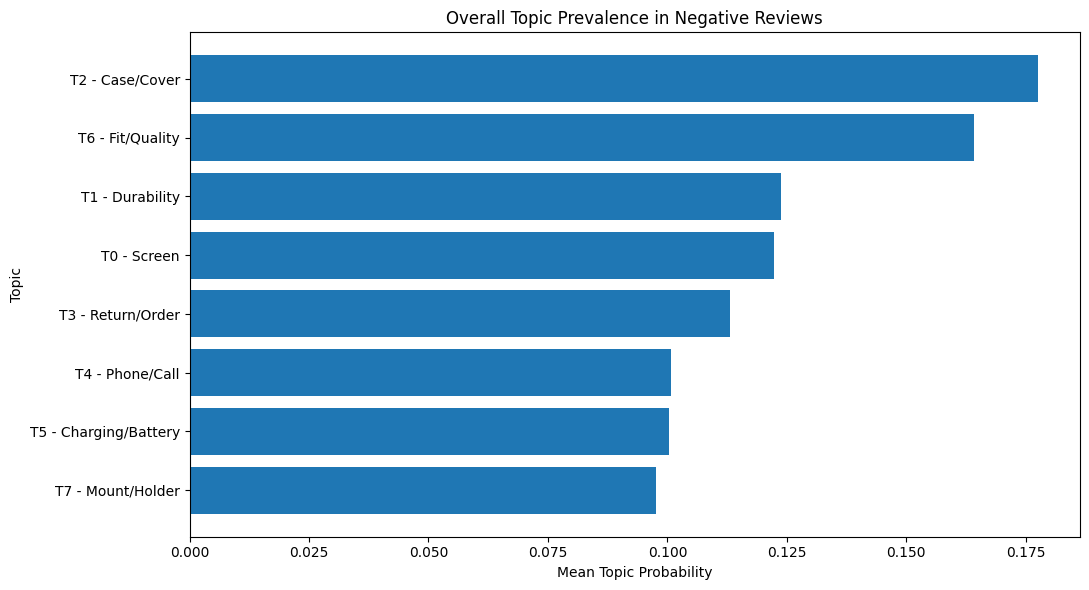

In [5]:
# Cell 3 — Overall LDA topic prevalence
import matplotlib.pyplot as plt
topic_names = {
    "topic_0_prob": "T0 - Screen",
    "topic_1_prob": "T1 - Durability",
    "topic_2_prob": "T2 - Case/Cover",
    "topic_3_prob": "T3 - Return/Order",
    "topic_4_prob": "T4 - Phone/Call",
    "topic_5_prob": "T5 - Charging/Battery",
    "topic_6_prob": "T6 - Fit/Quality",
    "topic_7_prob": "T7 - Mount/Holder"
}

plot_df = overall_topic_prevalence_df.copy()

plot_df["label"] = plot_df["topic"].map(topic_names)

plot_df = plot_df.sort_values(
    "mean_probability",
    ascending=True
)

plt.figure(figsize=(11, 6))

plt.barh(
    plot_df["label"],
    plot_df["mean_probability"]
)

plt.xlabel("Mean Topic Probability")
plt.ylabel("Topic")
plt.title(
    "Overall Topic Prevalence in Negative Reviews"
)

plt.tight_layout()
plt.show()

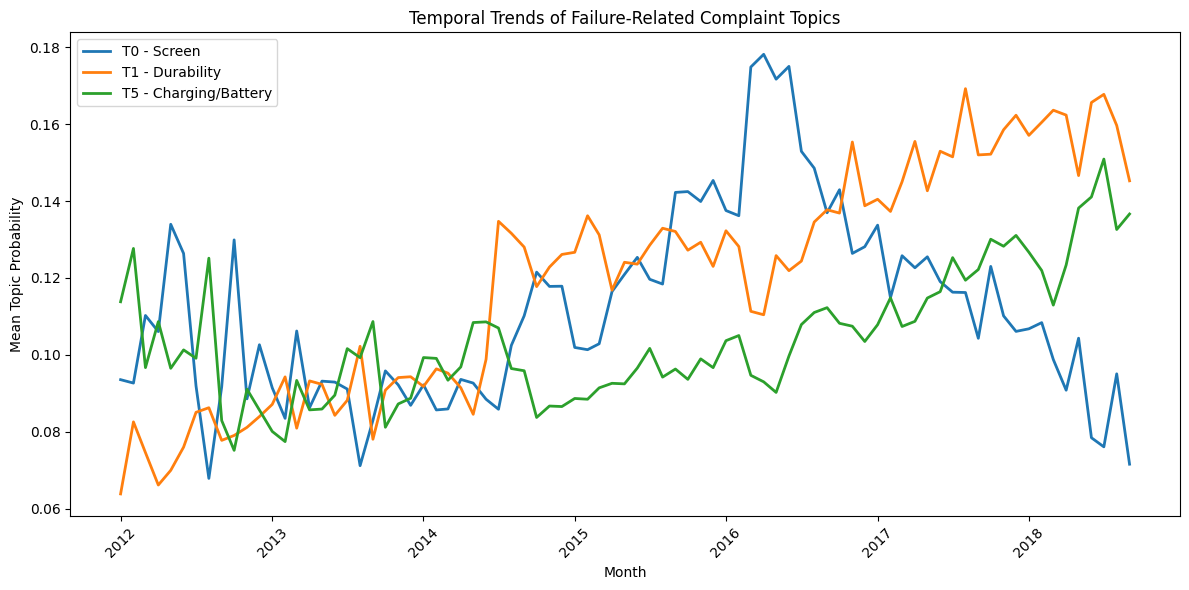

In [9]:
# Cell 4 — Temporal prevalence of failure-related topics

temporal_df["review_month"] = pd.to_datetime(
    temporal_df["review_month"].astype(str),
    format="%Y-%m",
    errors="coerce"
)

failure_topics = {
    "topic_0_prob": "T0 - Screen",
    "topic_1_prob": "T1 - Durability",
    "topic_5_prob": "T5 - Charging/Battery"
}

plt.figure(figsize=(12, 6))

for col, label in failure_topics.items():
    plt.plot(
        temporal_df["review_month"],
        temporal_df[col],
        label=label,
        linewidth=2
    )

plt.xlabel("Month")
plt.ylabel("Mean Topic Probability")
plt.title("Temporal Trends of Failure-Related Complaint Topics")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

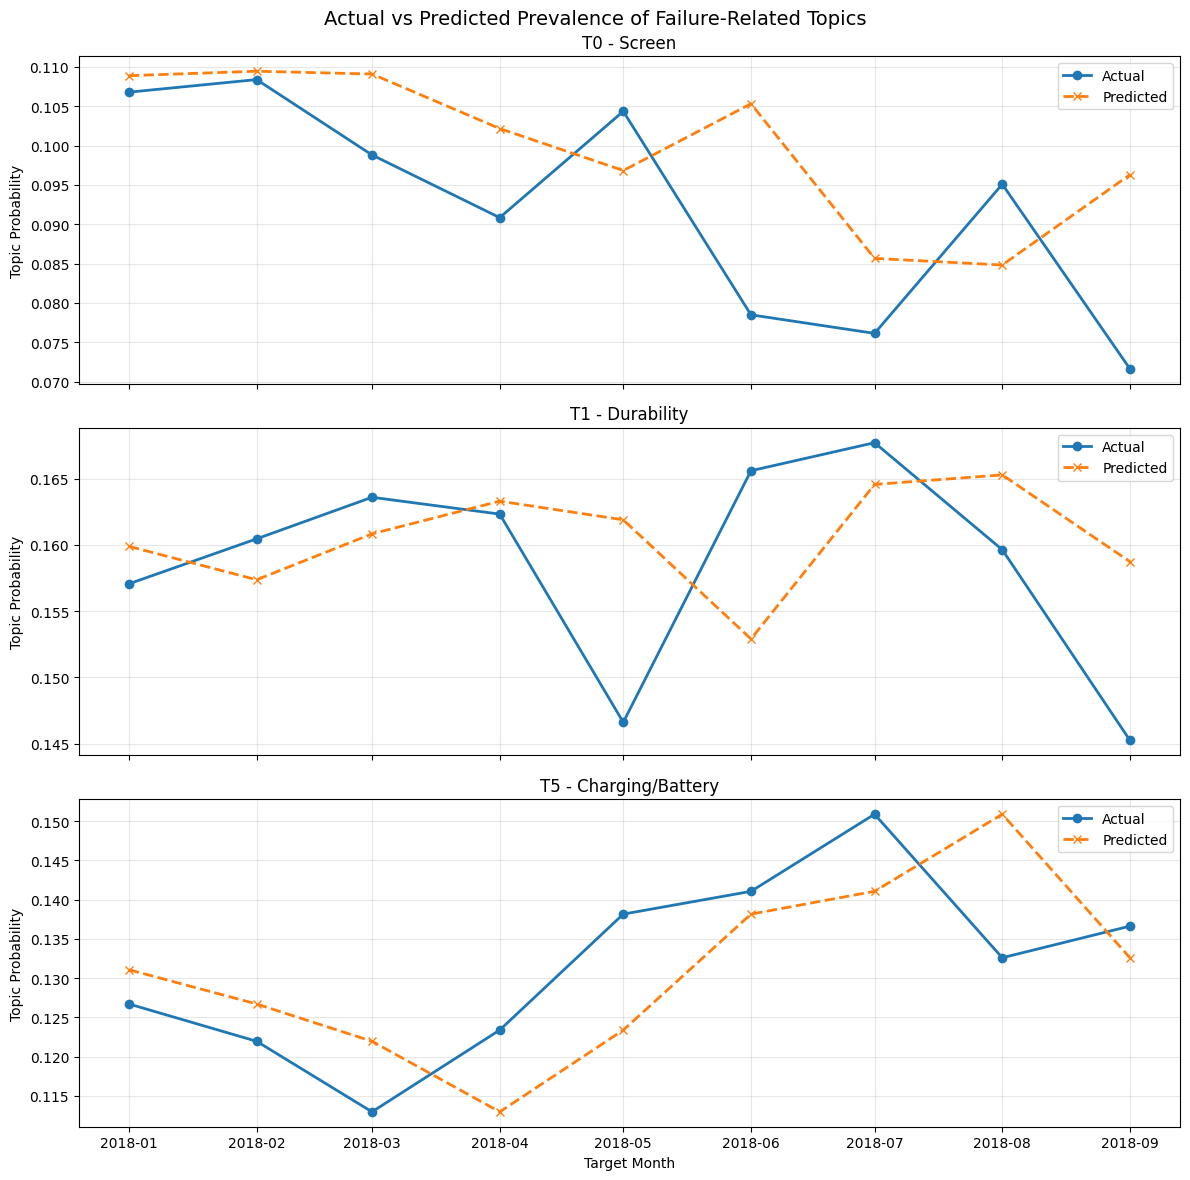

In [12]:
# Cell 5 — Actual vs Predicted for failure-related topics

forecast_plot_df = predictions_df.copy()

forecast_plot_df["target_month"] = pd.to_datetime(
    forecast_plot_df["target_month"],
    format="%Y-%m"
)

topic_labels = {
    "T0": "T0 - Screen",
    "T1": "T1 - Durability",
    "T5": "T5 - Charging/Battery"
}

fig, axes = plt.subplots(
    3, 1,
    figsize=(12, 12),
    sharex=True
)

for ax, topic_id in zip(axes, ["T0", "T1", "T5"]):

    df_topic = forecast_plot_df[
        forecast_plot_df["topic"] == topic_id
    ].sort_values("target_month")

    ax.plot(
        df_topic["target_month"],
        df_topic["actual"],
        marker="o",
        linewidth=2,
        label="Actual"
    )

    ax.plot(
        df_topic["target_month"],
        df_topic["predicted"],
        marker="x",
        linestyle="--",
        linewidth=2,
        label="Predicted"
    )

    ax.set_title(topic_labels[topic_id])
    ax.set_ylabel("Topic Probability")
    ax.legend()
    ax.grid(alpha=0.3)

axes[-1].set_xlabel("Target Month")

plt.suptitle(
    "Actual vs Predicted Prevalence of Failure-Related Topics",
    fontsize=14
)

plt.tight_layout()
plt.show()

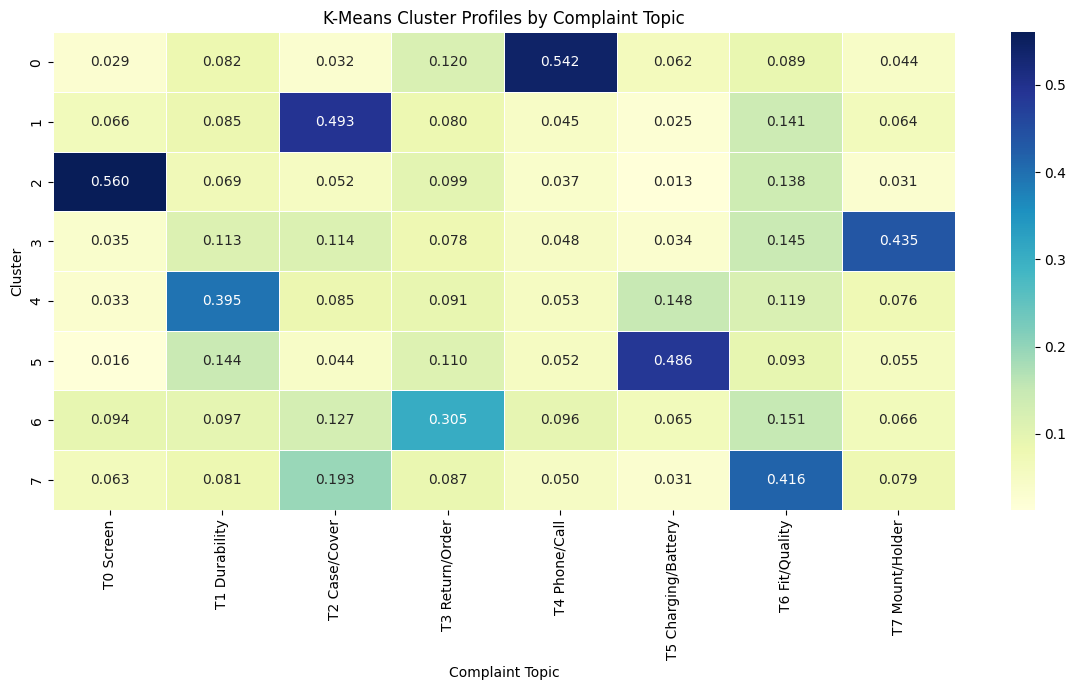

In [15]:
import seaborn as sns

# Cell 6 — K-Means cluster profile heatmap

topic_cols = [
    f"topic_{i}_prob"
    for i in range(8)
]

# Calculate cluster profiles from existing K-Means results
heatmap_data = (
    asin_cluster
    .groupby("cluster")[topic_cols]
    .mean()
)

# Rename topics for readability
heatmap_data.columns = [
    "T0 Screen",
    "T1 Durability",
    "T2 Case/Cover",
    "T3 Return/Order",
    "T4 Phone/Call",
    "T5 Charging/Battery",
    "T6 Fit/Quality",
    "T7 Mount/Holder"
]

plt.figure(figsize=(12, 7))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".3f",
    cmap="YlGnBu",
    linewidths=0.5
)

plt.title("K-Means Cluster Profiles by Complaint Topic")
plt.xlabel("Complaint Topic")
plt.ylabel("Cluster")

plt.tight_layout()
plt.show()

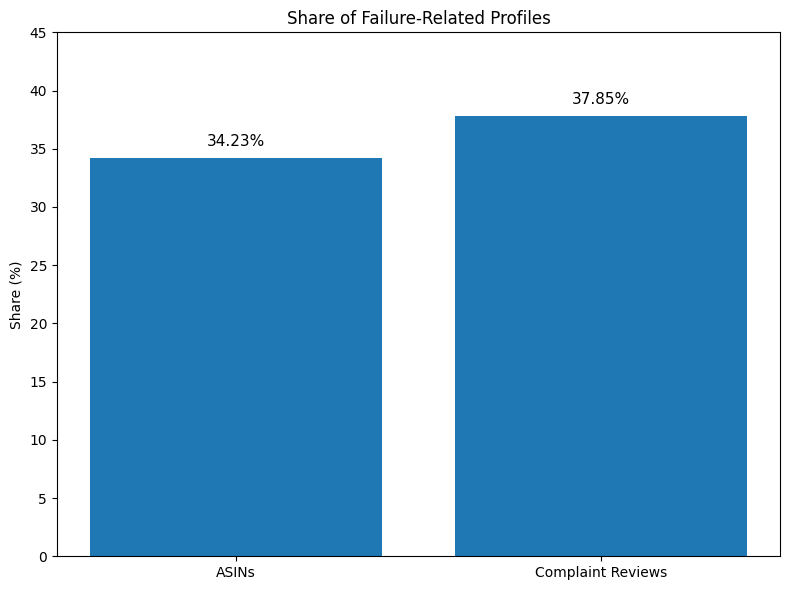

In [18]:
# Cell 7 — Failure-related profile share

share_plot_df = failure_share[
    failure_share["metric"].isin([
        "Failure-related ASIN share (%)",
        "Failure-related complaint review share (%)"
    ])
].copy()

# Short labels for visualization
share_plot_df["label"] = [
    "ASINs",
    "Complaint Reviews"
]

plt.figure(figsize=(8, 6))

bars = plt.bar(
    share_plot_df["label"],
    share_plot_df["value"]
)

plt.ylabel("Share (%)")
plt.title("Share of Failure-Related Profiles")

for bar, value in zip(bars, share_plot_df["value"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 1,
        f"{value:.2f}%",
        ha="center",
        fontsize=11
    )

plt.ylim(0, 45)
plt.tight_layout()
plt.show()

In [19]:
# Cell 8 — Final results summary

final_results = pd.DataFrame({
    "Analysis": [
        "LDA Topic Modeling",
        "Overall Topic Prevalence",
        "Temporal Analysis",
        "Forecasting",
        "K-Means Clustering",
        "Failure-related Profiles"
    ],
    "Result": [
        "8 complaint topics identified",
        "T2 Case/Cover and T6 Fit/Quality have the highest overall prevalence",
        "T0 Screen, T1 Durability, and T5 Charging/Battery show distinct temporal patterns",
        "T0 and T1 use Linear Regression; T5 uses Persistence Baseline",
        "8 ASIN complaint profiles identified",
        "3 profiles: Screen, Durability, Charging/Battery"
    ]
})

display(final_results)

,Analysis,Result
0,LDA Topic Modeling,8 complaint topics identified
1,Overall Topic Prevalence,T2 Case/Cover and T6 Fit/Quality have the high...
2,Temporal Analysis,"T0 Screen, T1 Durability, and T5 Charging/Batt..."
3,Forecasting,T0 and T1 use Linear Regression; T5 uses Persi...
4,K-Means Clustering,8 ASIN complaint profiles identified
5,Failure-related Profiles,"3 profiles: Screen, Durability, Charging/Battery"
